# 3.0 Data Preparation
## Online Gaming Behaviour Dataset

This notebook follows the CRISP-DM data preparation stages: **Data Selection**, **Data Cleaning**, **Data Standardisation**, and **Data Transformation (Enrichment)**, matching the structure of the accompanying Data Preparation report.

In [1]:
# Run this cell once to install required packages (skip if already installed)
import sys, subprocess
pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "missingno", "scikit-learn", "openpyxl"]
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])
except subprocess.CalledProcessError:
    # Falls back for "externally managed environment" systems (PEP 668)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "--break-system-packages", *pkgs])
print("Packages ready.")

Packages ready.


## Setup: Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", font_scale=0.95)
%matplotlib inline

# Ensure the output folder for saved figures exists
os.makedirs("figures", exist_ok=True)

## Load the Dataset

In [3]:
df = pd.read_csv("newonline_gaming_behavior_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
df.dtypes

PlayerID                       int64
Age                            int64
Gender                           str
Location                         str
GameGenre                        str
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
dtype: object

## 3.1 Data Selection

The first step involves reviewing the structure of the dataset to determine which attributes are relevant to the objective of analysing and predicting player engagement behaviour, and using a missing-value visualisation to inform this selection decision.

### 3.1.1 Missing Value Matrix (Figure 3.1)

C:\Users\chong\AppData\Local\Temp\ipykernel_21588\1729910840.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x500 with 0 Axes>

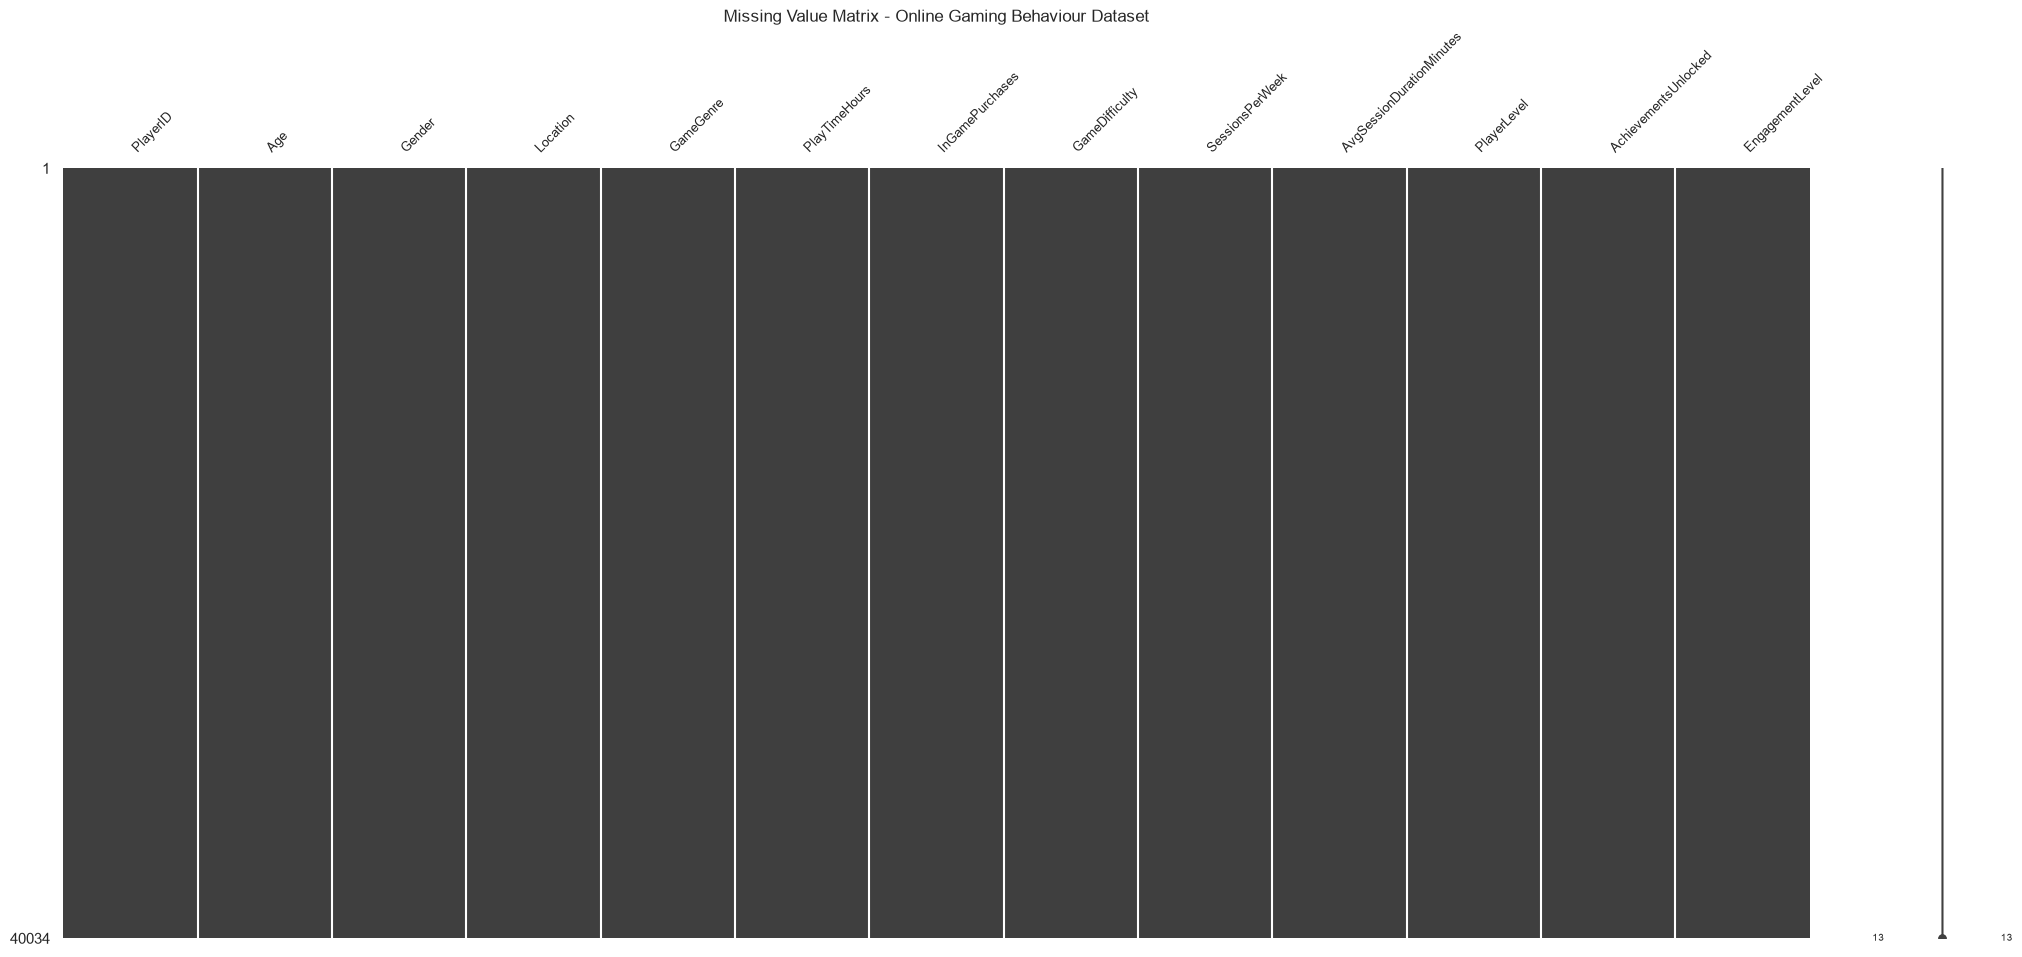

In [5]:
plt.figure(figsize=(10, 5))
msno.matrix(df, fontsize=9)
plt.title("Missing Value Matrix - Online Gaming Behaviour Dataset", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig1_missing_matrix.png", dpi=150)
plt.show()

### 3.1.2 Percentage of Missing Values (Figure 3.2)

PlayerID                     0.0
Age                          0.0
Gender                       0.0
Location                     0.0
GameGenre                    0.0
PlayTimeHours                0.0
InGamePurchases              0.0
GameDifficulty               0.0
SessionsPerWeek              0.0
AvgSessionDurationMinutes    0.0
PlayerLevel                  0.0
AchievementsUnlocked         0.0
EngagementLevel              0.0
dtype: float64


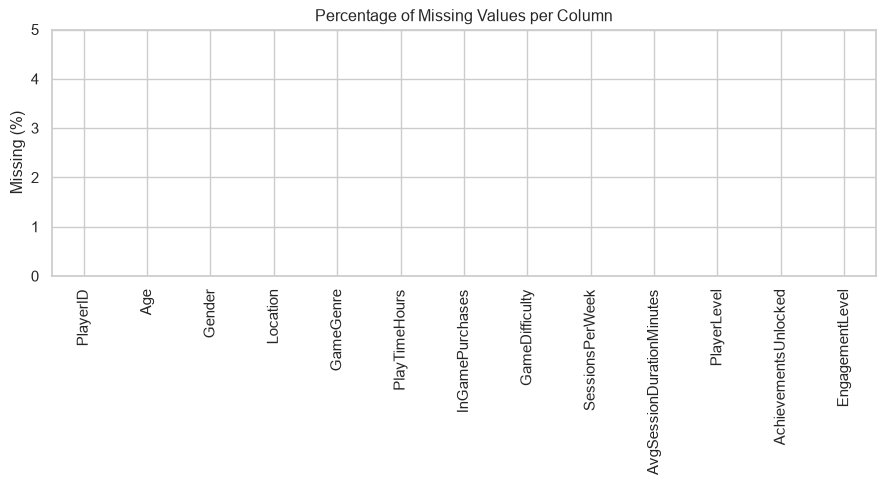

In [6]:
miss_pct = (df.isnull().sum() / len(df) * 100)
print(miss_pct)

plt.figure(figsize=(9, 5))
miss_pct.plot(kind="bar", color="#4C72B0")
plt.ylabel("Missing (%)")
plt.title("Percentage of Missing Values per Column")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("figures/fig2_missing_pct.png", dpi=150)
plt.show()

**Conclusion:** All 13 attributes recorded 0% missing values. Since no attribute exhibited missing data, there was no basis, on missingness grounds, to drop any column or row at the selection stage. Combined with the review of attribute relevance, all 13 attributes were retained. `PlayerID` is kept for record-tracking but will be excluded from the feature set prior to modelling.

## 3.2 Data Cleaning

With the attributes finalised in Section 3.1, data cleaning is performed on the retained rows: duplicate checking and outlier treatment (no imputation is required, since there are no missing values).

### 3.2.1 Duplicate Record Check

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated PlayerID values:", df["PlayerID"].duplicated().sum())
print("PlayerID range:", df["PlayerID"].min(), "-", df["PlayerID"].max())

Fully duplicated rows: 0
Duplicated PlayerID values: 0
PlayerID range: 9000 - 49033


### 3.2.2 Outlier Detection

Outliers are examined using the Interquartile Range (IQR) method on each attribute's **original, unscaled values**. For visualisation purposes only, the six numeric attributes are separately standardised to z-scores so they can be plotted side by side on a single boxplot despite being measured on different scales (e.g. Age in years vs. AvgSessionDurationMinutes in minutes). This standardisation is **not** used in the IQR calculation itself.

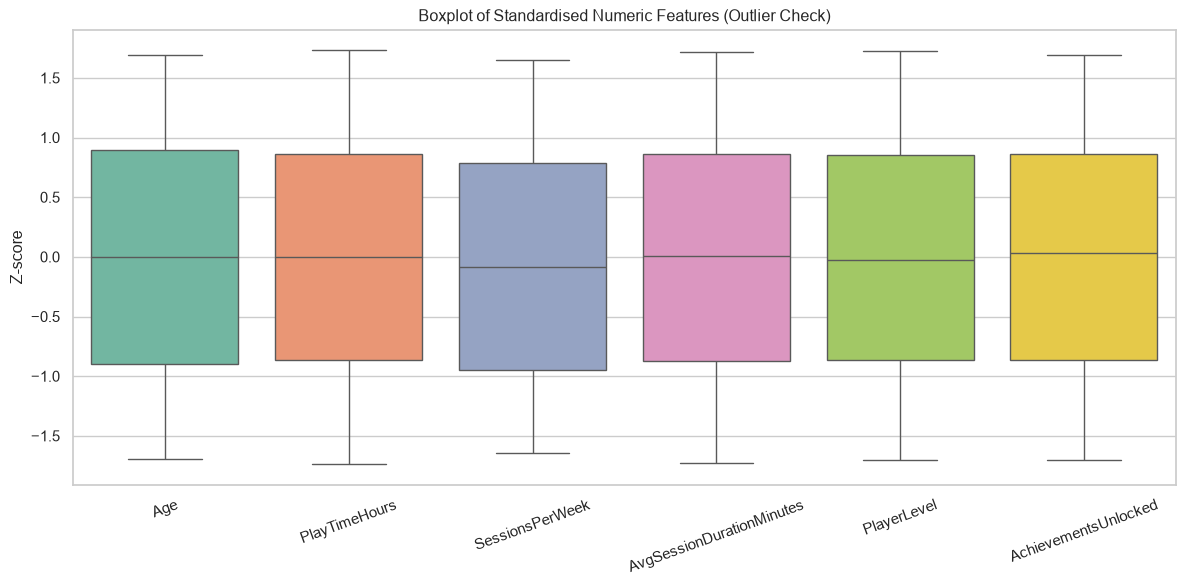

In [8]:
num_cols = ["Age", "PlayTimeHours", "SessionsPerWeek",
            "AvgSessionDurationMinutes", "PlayerLevel", "AchievementsUnlocked"]

# Boxplot on standardised values (visualisation only)
df_z = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_z, palette="Set2")
plt.title("Boxplot of Standardised Numeric Features (Outlier Check)")
plt.ylabel("Z-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figures/fig3_boxplot_numeric.png", dpi=150)
plt.show()

In [9]:
# IQR outlier detection on RAW (unscaled) values
outlier_summary = {}
for c in num_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_summary[c] = {"lower": round(lower, 2), "upper": round(upper, 2),
                           "n_outliers": int(n_out), "pct": round(n_out / len(df) * 100, 3)}

out_df = pd.DataFrame(outlier_summary).T
out_df

,lower,upper,n_outliers,pct
Age,-4.00,68.00,0.0,0.0
PlayTimeHours,-11.78,35.81,0.0,0.0
SessionsPerWeek,-11.00,29.00,0.0,0.0
AvgSessionDurationMinutes,-75.50,264.50,0.0,0.0
PlayerLevel,-48.50,147.50,0.0,0.0
AchievementsUnlocked,-25.50,74.50,0.0,0.0


**Conclusion:** No values fall outside the IQR bounds for any of the six numeric attributes. No rows were removed and no capping/winsorisation was necessary.

### 3.2.3 Correlation Heatmap (Figure 3.4)

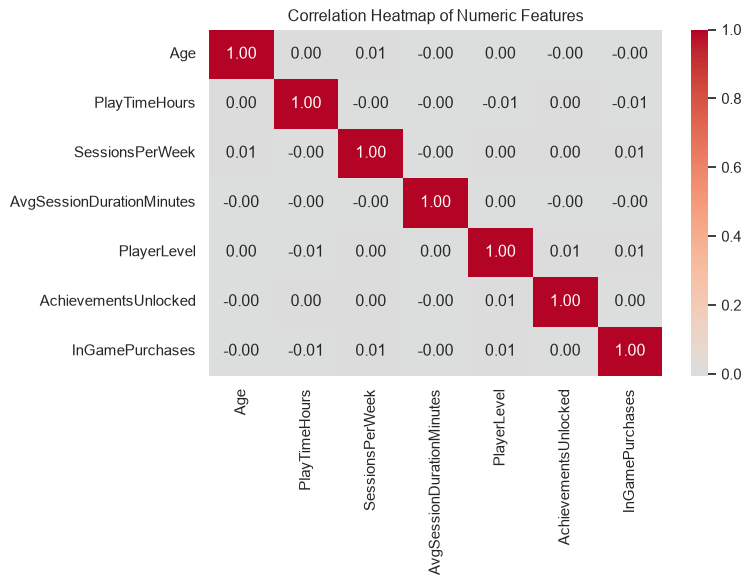

In [10]:
plt.figure(figsize=(8, 6))
corr = df[num_cols + ["InGamePurchases"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("figures/fig4_corr_heatmap.png", dpi=150)
plt.show()

All pairwise correlations are close to 0.00, confirming no attribute needs to be dropped on the grounds of redundancy.

## 3.3 Data Standardisation and Format Consistency

Checking the five categorical attributes for label consistency (inconsistent capitalisation, extra whitespace, spelling variants), and checking numeric attributes for logical validity.

In [11]:
cat_cols = ["Gender", "Location", "GameGenre", "GameDifficulty", "EngagementLevel"]
for c in cat_cols:
    print(c, ":", sorted(df[c].unique().tolist()))

Gender : ['Female', 'Male']
Location : ['Asia', 'Europe', 'Other', 'USA']
GameGenre : ['Action', 'RPG', 'Simulation', 'Sports', 'Strategy']
GameDifficulty : ['Easy', 'Hard', 'Medium']
EngagementLevel : ['High', 'Low', 'Medium']


### Distribution of Categorical Attributes (Figure 3.5)

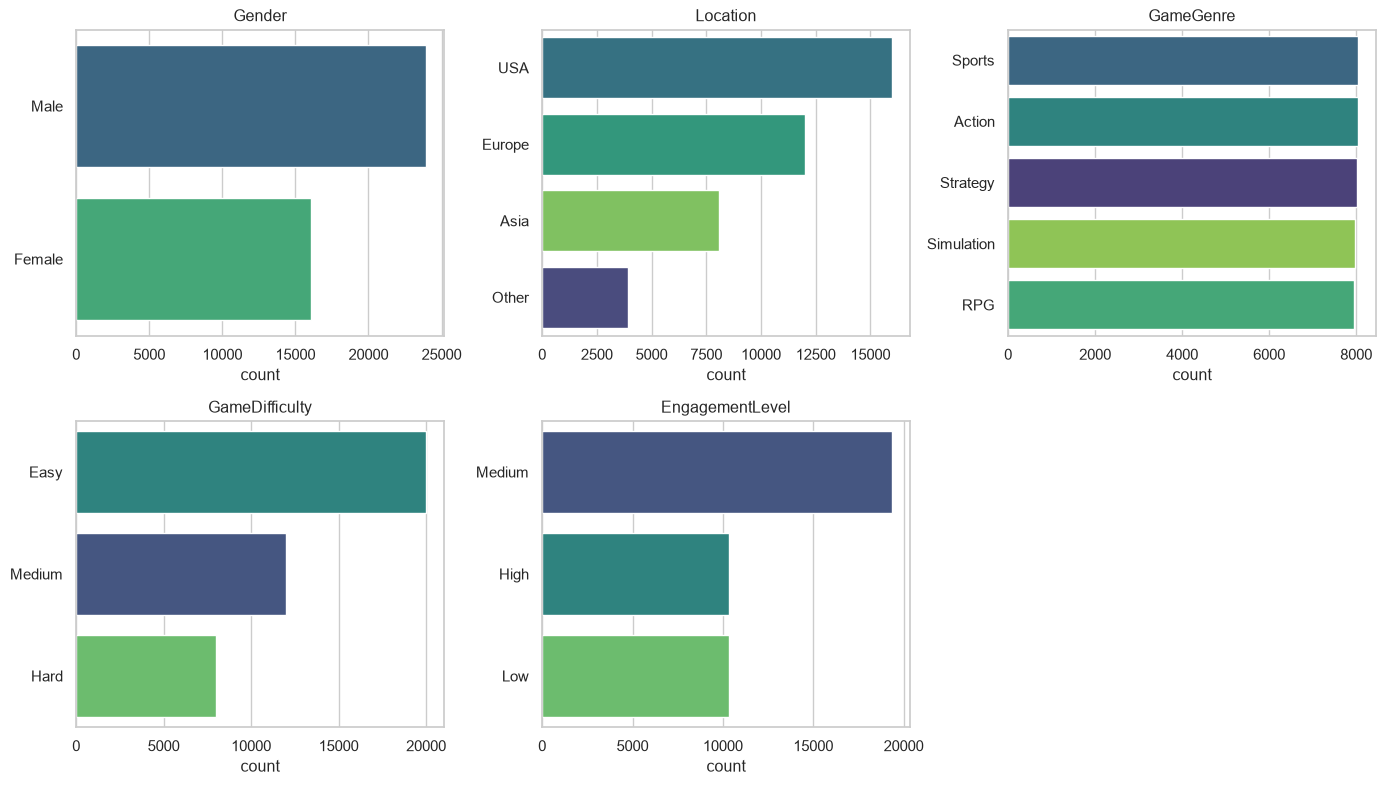

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, c in enumerate(cat_cols):
    order = df[c].value_counts().index
    sns.countplot(y=df[c], order=order, ax=axes[i], hue=df[c],
                  palette="viridis", legend=False)
    axes[i].set_title(c)
    axes[i].set_ylabel("")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("figures/fig5_categorical_dist.png", dpi=150)
plt.show()

In [13]:
# Logical validity checks on numeric columns
print("Age range:", df["Age"].min(), "-", df["Age"].max())
for c in num_cols:
    print(c, "min:", df[c].min())

Age range: 15 - 49
Age min: 15
PlayTimeHours min: 0.000114687
SessionsPerWeek min: 0
AvgSessionDurationMinutes min: 10
PlayerLevel min: 1
AchievementsUnlocked min: 0


**Conclusion:** No case-sensitivity conflicts, misspellings, or stray whitespace detected. No negative values found. The dataset is already internally consistent and correctly formatted.

## 3.4 Data Transformation and Enrichment

### 3.4.1 Categorical Encoding
- **Label (ordinal) encoding** — `GameDifficulty` (Easy=0, Medium=1, Hard=2) and `EngagementLevel` (Low=0, Medium=1, High=2), since both represent a meaningful order.
- **One-hot encoding** — `Gender`, `Location`, `GameGenre`, since these categories have no inherent ranking.

Note: one-hot encoding replaces the original Gender, Location and GameGenre columns with their encoded equivalents; no information is lost — each new column preserves the category membership of the original attribute.

In [14]:
df_t = df.copy()

# Ordinal encoding
difficulty_map = {"Easy": 0, "Medium": 1, "Hard": 2}
engagement_map = {"Low": 0, "Medium": 1, "High": 2}
df_t["GameDifficulty_enc"] = df_t["GameDifficulty"].map(difficulty_map)
df_t["EngagementLevel_enc"] = df_t["EngagementLevel"].map(engagement_map)

# One-hot encoding (nominal attributes)
df_t = pd.get_dummies(df_t, columns=["Gender", "Location", "GameGenre"], drop_first=False)

print("Shape after encoding:", df_t.shape)
df_t.head()

Shape after encoding: (40034, 23)


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Gender_Male,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,True,False,False,False,False,False,True
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,False,False,False,True,False,False,False,False,True
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,False,False,False,True,False,False,False,True,False
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,True,False,False,False,True,True,False,False,False,False
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,True,False,True,False,False,True,False,False,False,False


### 3.4.2 Feature Engineering (Data Enrichment)

Three attributes are engineered to enrich the dataset for deeper analysis:
1. **AgeGroup** — Age binned into four categories (15–20, 21–30, 31–40, 41–49).
2. **TotalWeeklyPlayMinutes** — SessionsPerWeek × AvgSessionDurationMinutes.
3. **AchievementRate** — AchievementsUnlocked ÷ PlayerLevel.

In [15]:
df_t["AgeGroup"] = pd.cut(df["Age"], bins=[14, 20, 30, 40, 50],
                           labels=["15-20", "21-30", "31-40", "41-49"])
df_t["TotalWeeklyPlayMinutes"] = df["SessionsPerWeek"] * df["AvgSessionDurationMinutes"]
df_t["AchievementRate"] = (df["AchievementsUnlocked"] / df["PlayerLevel"].replace(0, np.nan)).fillna(0)

print("Final transformed shape:", df_t.shape)
df_t.head()

Final transformed shape: (40034, 26)


,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


### Engagement Level across Engineered Age Groups (Figure 3.6)

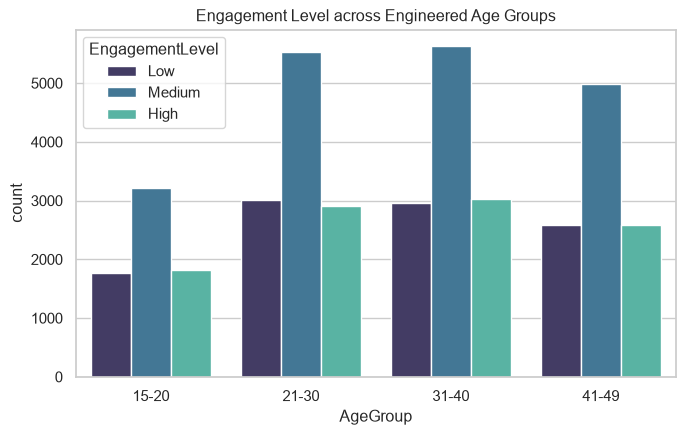

In [16]:
plt.figure(figsize=(7, 4.5))
sns.countplot(x=df_t["AgeGroup"], hue=df["EngagementLevel"],
              order=["15-20", "21-30", "31-40", "41-49"],
              hue_order=["Low", "Medium", "High"], palette="mako")
plt.title("Engagement Level across Engineered Age Groups")
plt.tight_layout()
plt.savefig("figures/fig6_agegroup_engagement.png", dpi=150)
plt.show()

## 3.5 Data Splitting

The transformed dataset is partitioned 70% training / 30% testing, using stratified sampling on `EngagementLevel` to preserve class proportions in both subsets.

In [17]:
feature_cols = [c for c in df_t.columns if c not in
                ["PlayerID", "EngagementLevel", "EngagementLevel_enc", "AgeGroup"]]
X = df_t[feature_cols]
y = df_t["EngagementLevel_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (28023, 22)
Test shape: (12011, 22)


## 3.6 Export Processed Dataset

In [18]:
df_t.to_csv("processed_gaming_dataset.csv", index=False)
print("Saved processed_gaming_dataset.csv with shape:", df_t.shape)

Saved processed_gaming_dataset.csv with shape: (40034, 26)


## Summary

| Step | Finding | Action Taken |
|---|---|---|
| Data Selection | 13 relevant attributes; no irrelevant columns | All attributes retained; PlayerID excluded from modelling features only |
| Missing Values | 0% missing across all attributes | No imputation required |
| Duplicates | No duplicate rows or PlayerIDs | No rows removed |
| Outliers | 0 outliers detected (IQR method) | No rows removed or capped |
| Format Consistency | Categorical labels already clean | No text correction required |
| Encoding | Ordinal + nominal attributes identified | Label encoding (GameDifficulty, EngagementLevel); one-hot encoding (Gender, Location, GameGenre) |
| Enrichment | Opportunity for segment-level/ratio insight | Added AgeGroup, TotalWeeklyPlayMinutes, AchievementRate |
| Data Splitting | Need for unbiased model evaluation | 70/30 stratified train-test split |
